# Chapter 8 companion — Bias–variance decomposition from zero


## Topic 0 — What this notebook will do


### 0.1 The destination, stated without symbols

Chapter 8 eventually separates an average squared prediction mistake into three parts.

We will not display the final equation yet because its symbols and technical terms have not been defined. We will build the required ideas one at a time and name each part only after explaining what it measures.


### 0.2 Always ask what is fixed and what is allowed to vary

Every average in this notebook describes a repeated experiment. Before reading an average, ask:

- What stays fixed?
- What is repeatedly drawn again?
- What number is calculated on each repetition?

At each stage, the notebook will explicitly identify those three pieces before performing the average. We will not combine multiple repeated experiments until each one has been introduced separately.


## Topic 1 — One input and repeated target observations


### 1.1 One data example contains an input and a target

An **input** is the information given to a prediction system. The book denotes it by $x$.

A **target** is the value we want to predict. The book writes the target at input $x$ as

$$
y[x].
$$

In this notebook, both $x$ and $y[x]$ are scalar values. A scalar is one number rather than a list of numbers.

Example: $x$ might be the measured size of a house and $y[x]$ its sale price.


### 1.2 First hold one input value fixed

Choose one particular input and do not change it. For example, imagine considering houses with the same recorded features $x$.

Even with the same recorded input, the target need not always be identical. Unrecorded conditions can make one sale price higher and another lower.

The Chapter 8 derivation first studies this vertical question:

> At this fixed $x$, what targets could be observed?


### 1.3 A random variable produces one value per repetition

Call $y[x]$ a **random variable** because its value is not known before the observation is drawn.

On one repetition, $y[x]$ produces one scalar. On another repetition at the same $x$, it may produce another scalar.

Suppose its possible values are $8$, $10$, and $12$. Then:

- $y[x]$ is the random scalar;
- $\{8,10,12\}$ is the set of values it can take;
- $[8,10,12]^T$ is an optional computational vector listing those values.

The book's symbol $y[x]$ does not mean the whole vector. Each draw of $y[x]$ returns one of the possible scalar values.


### 1.4 Probability says how often each value occurs in repeated draws

A **target distribution** is the list of possible target values together with the probability of each value. Suppose the fixed input has this target distribution:

| Possible target $y[x]$ | Probability |
|---:|---:|
| $8$ | $0.25$ |
| $10$ | $0.50$ |
| $12$ | $0.25$ |

A probability is a number from $0$ to $1$. The three probabilities add to $1$:

$$
0.25+0.50+0.25=1.
$$

In many repeated draws at the same $x$, about $25\%$ would produce $8$, about $50\%$ would produce $10$, and about $25\%$ would produce $12$.


### 1.5 The mean is a probability-weighted average

Multiply each possible target by its probability and add:

$$
0.25(8)+0.50(10)+0.25(12)=10.
$$

This weighted average is the **mean target at input $x$**. The book denotes it by $\mu[x]$:

$$
\mu[x]=10.
$$

The expectation symbol $\mathbb E$ means “take the probability-weighted average.” Therefore,

$$
\mu[x]=\mathbb E_y[y[x]].
$$

Read the subscript $y$ as:

> Average over repeated draws of the random target $y[x]$, while $x$ remains fixed.


### 1.6 A deviation is a value minus its mean

For each possible target, calculate its distance from the mean:

| $y[x]$ | Deviation $y[x]-\mu[x]$ |
|---:|---:|
| $8$ | $-2$ |
| $10$ | $0$ |
| $12$ | $2$ |

Negative and positive deviations cancel in the weighted average:

$$
0.25(-2)+0.50(0)+0.25(2)=0.
$$

This is not an accident. A random variable's deviations from its own mean always have expectation zero:

$$
\mathbb E_y[y[x]-\mu[x]]=0.
$$


### 1.7 Squaring prevents negative and positive deviations from canceling

To measure spread, square every deviation:

| $y[x]$ | $y[x]-\mu[x]$ | $(y[x]-\mu[x])^2$ |
|---:|---:|---:|
| $8$ | $-2$ | $4$ |
| $10$ | $0$ | $0$ |
| $12$ | $2$ | $4$ |

The probability-weighted average squared deviation is

$$
0.25(4)+0.50(0)+0.25(4)=2.
$$


### 1.8 Variance is the average squared deviation from the mean

Variation in the target that the fixed input does not determine is called **target noise**.

The **variance** of the target at this fixed input is

$$
\mathbb E_y[(y[x]-\mu[x])^2].
$$

Chapter 8 calls this the noise variance and denotes it by $\sigma^2$:

$$
\sigma^2
=\mathbb E_y[(y[x]-\mu[x])^2].
$$

Because squaring removes the sign, the equivalent form used by the book is

$$
\sigma^2
=\mathbb E_y[(\mu[x]-y[x])^2].
$$

For our three-value example, $\sigma^2=2$.


### 1.9 Visualize repeated targets at one fixed input

The orange points below represent repeated possible target observations at the same fixed input. The blue line marks their mean. The horizontal spread around that line is the target noise.


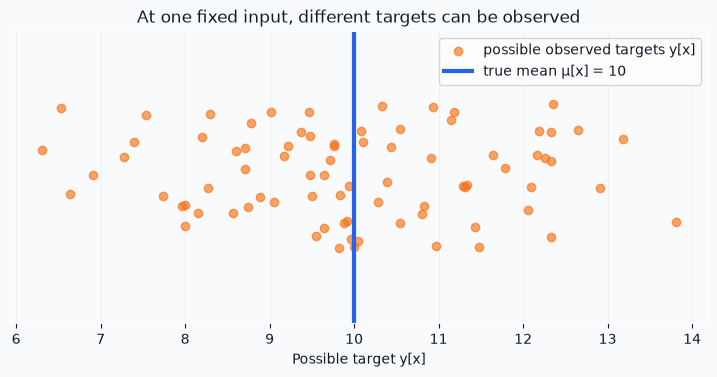

In [1]:
from typing import TypeAlias

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from numpy.typing import NDArray

FloatArray: TypeAlias = NDArray[np.float64]

RANDOM_SEED: int = 8
rng: np.random.Generator = np.random.default_rng(RANDOM_SEED)
fixed_x: float = 0.25
true_mean_at_x: float = 10.0
noise_standard_deviation: float = 1.5
possible_targets: FloatArray = rng.normal(
    true_mean_at_x, noise_standard_deviation, size=80
)

noise_figure: Figure
noise_axis: Axes
noise_figure, noise_axis = plt.subplots(figsize=(9, 3.8), facecolor="#f8fafc")
noise_axis.set_facecolor("#f8fafc")
vertical_jitter: FloatArray = rng.uniform(-0.08, 0.08, size=len(possible_targets))
noise_axis.scatter(possible_targets, vertical_jitter, color="#f97316", alpha=0.65,
                   label="possible observed targets y[x]")
noise_axis.axvline(true_mean_at_x, color="#2563eb", linewidth=3,
                   label="true mean μ[x] = 10")
noise_axis.set(title="At one fixed input, different targets can be observed",
               xlabel="Possible target y[x]", yticks=[], ylim=(-0.16, 0.16))
noise_axis.tick_params(colors="#111827"); noise_axis.title.set_color("#111827")
noise_axis.xaxis.label.set_color("#111827")
noise_axis.legend(facecolor="white", labelcolor="#111827"); noise_axis.grid(axis="x", alpha=0.2)
plt.show()


## Topic 2 — Expectation, transformations, and varying inputs


### 2.1 The brackets say what to calculate before averaging

We already saw

$$
\mathbb E_y[y[x]],
$$

which averages target values themselves.

The expression inside the brackets can instead be a calculation performed on each target. For example,

$$
\mathbb E_y[(y[x]-10)^2]
$$

means:

1. Draw or consider a possible $y[x]$.
2. Calculate $(y[x]-10)^2$.
3. Repeat for all possible targets.
4. Take the probability-weighted average of the calculated values.


### 2.2 A function is a recipe that turns an input value into an output value

A function named $g$ can be defined by

$$
g(u)=(u-10)^2.
$$

Here, $u$ is a placeholder for the value supplied to the recipe. For example,

$$
g(8)=4,
\qquad
g(10)=0,
\qquad
g(12)=4.
$$

After defining the recipe, we may supply the random scalar $y[x]$:

$$
g(y[x])=(y[x]-10)^2.
$$

For one realized value of $y[x]$, $g(y[x])$ returns one scalar. The notation

$$
\mathbb E_y[g(y[x])]
$$

means to apply that recipe separately to every possible target and then average the results using the target probabilities.


### 2.3 A vector calculation can list all discrete possibilities

A vector is an ordered list of numbers. We may store the possible targets and probabilities as

$$
\mathbf y_x=
\begin{bmatrix}8\\10\\12\end{bmatrix},
\qquad
\mathbf p_x=
\begin{bmatrix}0.25\\0.50\\0.25\end{bmatrix}.
$$

Applying $g$ element by element gives

$$
g(\mathbf y_x)
=
\begin{bmatrix}4\\0\\4\end{bmatrix}.
$$

A dot product means “multiply matching entries and add.” Thus,

$$
\begin{aligned}
\mathbf p_x^Tg(\mathbf y_x)
&=0.25(4)+0.50(0)+0.25(4)\\
&=2.
\end{aligned}
$$

This vector is a computational representation. In the mathematical expectation, $y[x]$ and $g(y[x])$ are scalar random quantities.


### 2.4 The vertical bar means “given this fixed input”

The notation

$$
\Pr(y\mid x)
$$

is read “the distribution of $y$ given $x$.” It answers:

> After fixing this particular input $x$, how likely are the possible target values?

A different input can have a different target distribution. Therefore, $\Pr(y\mid x=1)$ need not be the same as $\Pr(y\mid x=3)$.


### 2.5 An integral is the continuous version of a weighted sum

A target is **continuous** when it can take any real-number value within a range, rather than only values from a finite list. There are then infinitely many possibilities, so we cannot list all of them in a finite table.

For continuous values, $\Pr(y\mid x)$ is a **density**. A density is a function whose area over an interval gives the probability of landing in that interval.

For a tiny interval of width $dy$ near a possible target $y$, its approximate probability is

$$
\Pr(y\mid x)\,dy.
$$

The contribution of that tiny interval to the expectation is

$$
g(y[x])\Pr(y\mid x)\,dy.
$$

An integral adds all these tiny weighted contributions:

$$
\mathbb E_y[g(y[x])]
=\int g(y[x])\Pr(y\mid x)\,dy.
$$

This equation still fixes $x$. It averages over all possible targets at that one input position.


### 2.6 When $x$ varies, data are generated in two stages

An **input distribution** lists or describes the possible input values and how frequently they occur. Write it as $\Pr(x)$.

A complete data-generating experiment is:

1. Draw an input $x$ from the input distribution $\Pr(x)$.
2. After $x$ is known, draw a target $y[x]$ from $\Pr(y\mid x)$.

For a concrete continuous example, suppose

$$
y[x]=2x+\epsilon,
$$

where $\epsilon$ is random noise from a bell-shaped distribution centered at zero.

At $x=1$, targets are centered near $2$. At $x=2$, they are centered near $4$. At $x=3$, they are centered near $6$.


### 2.7 Averaging over targets produces one result for every $x$

Define

$$
h[x]
=\mathbb E_y[g(y[x])].
$$

For one fixed $x$, the expectation returns one number. When $x$ changes, $\Pr(y\mid x)$ may change, so that number may change too. The collection of results is therefore a function $h[x]$.

If $g(u)=u$ in the example $y[x]=2x+\epsilon$, then

$$
h[x]=\mathbb E_y[y[x]]=2x.
$$

The notation $\mathbb E_y$ is shorthand for averaging over targets while $x$ is fixed. A more explicit notation would be $\mathbb E_{y\mid x}$.


### 2.8 A second expectation averages over varying inputs

After calculating $h[x]$ at every input, average those results using the input distribution:

$$
\mathbb E_x[h[x]]
=\int h[x]\Pr(x)\,dx.
$$

Substitute $h[x]=\mathbb E_y[g(y[x])]$:

$$
\mathbb E_x\mathbb E_y[g(y[x])]
=
\int
\left[
\int g(y[x])\Pr(y\mid x)\,dy
\right]
\Pr(x)\,dx.
$$

Read from the inside outward:

1. Fix $x$ and average over possible targets.
2. Move across possible inputs and average the first results.


### 2.9 Visualize both stages

In the left plot, each point is produced by first choosing an $x$ and then drawing one random $y[x]$. In the right plot, each curve shows the conditional target density at one fixed input.


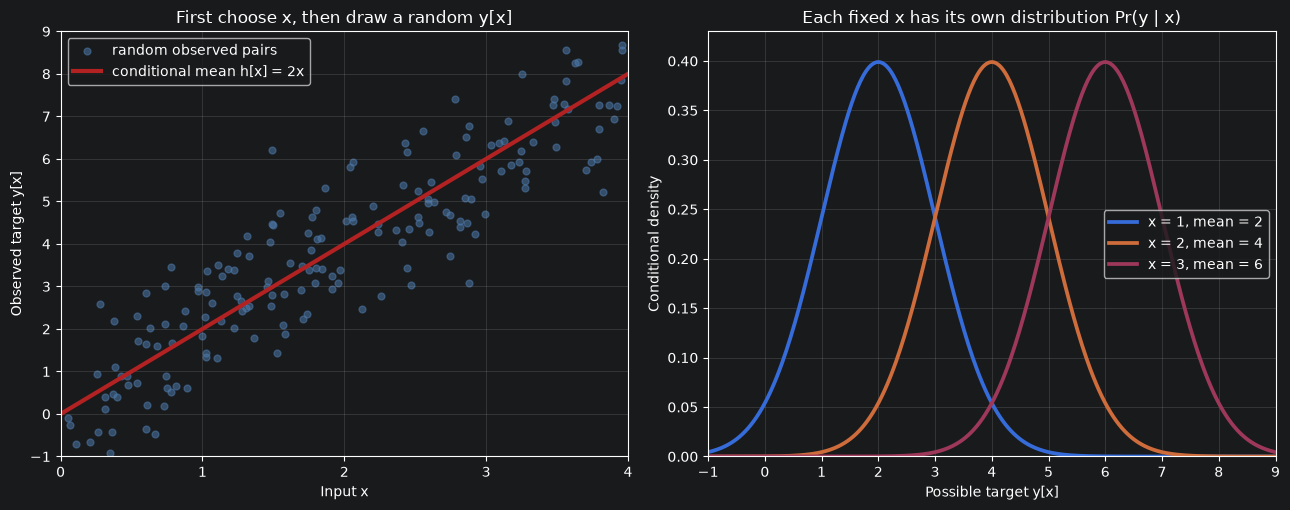

In [2]:
rng: np.random.Generator = np.random.default_rng(8)
x_samples: np.ndarray = rng.uniform(0.0, 4.0, size=180)
y_samples: np.ndarray = 2.0 * x_samples + rng.normal(0.0, 1.0, size=x_samples.shape)
x_grid: np.ndarray = np.linspace(0.0, 4.0, 240)
y_grid: np.ndarray = np.linspace(-1.0, 9.0, 400)
selected_x: np.ndarray = np.array([1.0, 2.0, 3.0])

figure: Figure
axes: np.ndarray
figure, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(x_samples, y_samples, s=24, alpha=0.55, color="#4C78A8", label="random observed pairs")
axes[0].plot(x_grid, 2.0 * x_grid, color="#B22222", linewidth=3.0, label="conditional mean h[x] = 2x")
axes[0].set(
    title="First choose x, then draw a random y[x]",
    xlabel="Input x",
    ylabel="Observed target y[x]",
    xlim=(0.0, 4.0),
    ylim=(-1.0, 9.0),
    xticks=np.arange(0.0, 4.1, 1.0),
    yticks=np.arange(-1.0, 9.1, 1.0),
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.25)

fixed_x: np.float64
for fixed_x in selected_x:
    conditional_density: np.ndarray = np.exp(-0.5 * (y_grid - 2.0 * fixed_x) ** 2) / np.sqrt(2.0 * np.pi)
    axes[1].plot(y_grid, conditional_density, linewidth=2.7, label=f"x = {fixed_x:.0f}, mean = {2.0 * fixed_x:.0f}")

axes[1].set(
    title="Each fixed x has its own distribution Pr(y | x)",
    xlabel="Possible target y[x]",
    ylabel="Conditional density",
    xlim=(-1.0, 9.0),
    ylim=(0.0, 0.43),
    xticks=np.arange(-1.0, 9.1, 1.0),
)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.25)

figure.tight_layout()
plt.show()


## Topic 3 — Random training datasets produce random fitted models


### 3.1 A training dataset is a finite collection of examples

Write one training dataset as

$$
\mathcal D
=\{(x_1,y[x_1]),\ldots,(x_N,y[x_N])\}.
$$

Here, $N$ is the number of training examples. The population is the full data-generating process from which examples can be drawn; $\mathcal D$ is one finite sample from it.


### 3.2 Training turns a dataset into fitted parameters

A **model** is a mathematical rule used to turn an input into a prediction. A model contains adjustable numbers called **parameters**. Training is the procedure that adjusts those numbers using the examples in $\mathcal D$.

The book denotes the fitted parameters by

$$
\phi[\mathcal D].
$$

The brackets emphasize that the learned parameter values depend on which dataset was supplied to training.


### 3.3 The fitted model maps an input to a prediction

The book writes

$$
f[x,\phi[\mathcal D]]
$$

for the prediction at input $x$ made using parameters trained on $\mathcal D$.

Read the two inputs to $f$ as:

- $x$: where to make the prediction;
- $\phi[\mathcal D]$: which fitted parameter values to use.

Once $\mathcal D$ and the training procedure are fixed, this prediction is one scalar number.


### 3.4 A new sampled dataset usually produces a new fitted function

Repeat the training experiment:

1. Draw $N$ examples to form $\mathcal D_1$.
2. Train and obtain $\phi[\mathcal D_1]$.
3. Draw another $N$ examples to form $\mathcal D_2$.
4. Train and obtain $\phi[\mathcal D_2]$.

The datasets come from the same population and use the same sample size. They are new independent draws, meaning one draw does not determine the next. They can still overlap by chance.

Because the examples differ, the fitted predictions at the same $x$ can differ:

$$
f[x,\phi[\mathcal D_1]]
\ne
f[x,\phi[\mathcal D_2]].
$$


### 3.5 Equation 8.4 defines the expected model output

Now average the prediction over all datasets that the sampling process could produce:

$$
f_{\mu}[x]
=\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]\right].
$$

The subscript $\mathcal D$ means:

> Repeatedly sample a training dataset, retrain using the same procedure, evaluate at the same $x$, and average the predictions.

The population, sample size $N$, model form, training procedure, and evaluation input remain fixed. The sampled dataset changes.

This is a theoretical expectation over the distribution of all possible datasets. It does not specify a finite number of retrainings.


### 3.6 A finite number of retrainings estimates the expectation

Let $R$ be the number of times we repeat the dataset-and-training experiment. With datasets $\mathcal D_1,\ldots,\mathcal D_R$, calculate

$$
\widehat f_{\mu}^{(R)}[x]
=
\frac{1}{R}
\sum_{r=1}^{R}
f[x,\phi[\mathcal D_r]].
$$

This is called a **Monte Carlo estimate**: an unknown expectation is approximated by averaging results from repeated random simulations.

As $R$ becomes large, the estimate generally stabilizes toward the theoretical value:

$$
\widehat f_{\mu}^{(R)}[x]
\longrightarrow f_{\mu}[x].
$$

There is no universal correct $R$. More repetitions improve stability but cost more computation. A practical check is whether adding more repetitions materially changes the running average.


### 3.7 A finite average of model predictions is an ensemble prediction

An **ensemble** is a group of separately fitted models whose predictions are combined.

At one $x$, $\widehat f_{\mu}^{(R)}[x]$ is the average prediction of a finite ensemble. Calculating it at every input produces an ensemble function.

The difference is:

- $\widehat f_{\mu}^{(R)}[x]$: a finite approximation using $R$ trained models;
- $f_{\mu}[x]$: the ideal expectation over every dataset the sampling process could produce.

The theoretical $f_{\mu}[x]$ can be viewed as an idealized population-level ensemble.


### 3.8 Equation 8.4 averages predictions, not parameters

In general,

$$
\frac{1}{R}
\sum_{r=1}^{R}
f[x,\phi[\mathcal D_r]]
\ne
f\left[
x,
\frac{1}{R}
\sum_{r=1}^{R}\phi[\mathcal D_r]
\right].
$$

The left side predicts with every model and then averages the predictions. The right side first averages parameter values and then predicts once.

These operations are generally different for neural networks. “Nonlinear in the parameters” means that averaging parameter inputs to the model does not generally produce the same result as averaging the outputs produced by those parameters. Equation 8.4 uses the left side.


### 3.9 Model variance measures spread across retrained predictions

At a fixed $x$, each fitted model can deviate from the expected model output $f_{\mu}[x]$. The average squared deviation is

$$
\mathbb E_{\mathcal D}
\left[
(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2
\right].
$$

This quantity is called **model variance**. Its square root is called model standard deviation and has the same units as the prediction.

Model variance asks how sensitive the learning procedure is to the particular training sample.


### 3.10 Visualize retraining on $R=100$ datasets

The following simulation repeatedly samples $N=12$ noisy examples and fits the same degree-five polynomial model, meaning a curve built from powers up to $x^5$.

The light-blue curves are individual fitted functions. The red curve is the finite estimate $\widehat f_{\mu}^{(100)}[x]$, not the exact theoretical $f_{\mu}[x]$. The shaded band shows one model standard deviation on either side of that estimate.


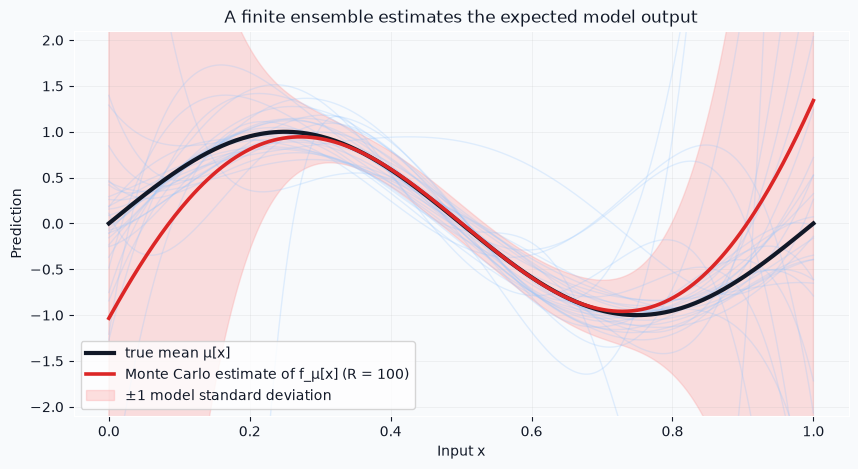

In [3]:
def true_function(x_values: FloatArray) -> FloatArray:
    return np.sin(2 * np.pi * x_values)


number_of_datasets: int = 100  # Finite Monte Carlo budget, not a theoretical requirement.
training_examples_per_dataset: int = 12
polynomial_degree: int = 5
data_noise_standard_deviation: float = 0.25
x_grid: FloatArray = np.linspace(0.0, 1.0, 300)
true_mean_curve: FloatArray = true_function(x_grid)
model_predictions: list[FloatArray] = []

for dataset_index in range(number_of_datasets):
    dataset_x: FloatArray = np.sort(rng.uniform(0.0, 1.0, training_examples_per_dataset))
    dataset_y: FloatArray = (
        true_function(dataset_x)
        + rng.normal(0.0, data_noise_standard_deviation, training_examples_per_dataset)
    )
    polynomial_coefficients: FloatArray = np.polyfit(
        dataset_x, dataset_y, deg=polynomial_degree
    )
    fitted_curve: FloatArray = np.polyval(polynomial_coefficients, x_grid)
    model_predictions.append(fitted_curve)

prediction_matrix: FloatArray = np.stack(model_predictions)
estimated_expected_model_curve: FloatArray = prediction_matrix.mean(axis=0)
model_standard_deviation_curve: FloatArray = prediction_matrix.std(axis=0)

fits_figure: Figure
fits_axis: Axes
fits_figure, fits_axis = plt.subplots(figsize=(10, 5), facecolor="#f8fafc")
fits_axis.set_facecolor("#f8fafc")
for fitted_curve in prediction_matrix[:30]:
    fits_axis.plot(x_grid, fitted_curve, color="#93c5fd", alpha=0.25, linewidth=1)
fits_axis.plot(x_grid, true_mean_curve, color="#111827", linewidth=3,
               label="true mean μ[x]")
fits_axis.plot(x_grid, estimated_expected_model_curve, color="#dc2626", linewidth=2.6,
               label=f"Monte Carlo estimate of f_μ[x] (R = {number_of_datasets})")
fits_axis.fill_between(
    x_grid,
    estimated_expected_model_curve - model_standard_deviation_curve,
    estimated_expected_model_curve + model_standard_deviation_curve,
    color="#fca5a5",
    alpha=0.35,
    label="±1 model standard deviation",
)
fits_axis.set(title="A finite ensemble estimates the expected model output",
              xlabel="Input x", ylabel="Prediction")
fits_axis.set_ylim(-2.1, 2.1)
fits_axis.tick_params(colors="#111827"); fits_axis.title.set_color("#111827")
fits_axis.xaxis.label.set_color("#111827"); fits_axis.yaxis.label.set_color("#111827")
fits_axis.legend(facecolor="white", labelcolor="#111827"); fits_axis.grid(alpha=0.2)
plt.show()


### 3.11 Target noise variance and model variance are different

| Quantity | Repeatedly redraw | Keep fixed |
|---|---|---|
| Noise variance | Fresh target $y[x]$ | $x$ and fitted model |
| Model variance | Training dataset $\mathcal D$ and fitted model | $x$ and data-generating population |

Their formulas are

$$
\underbrace{\mathbb E_y[(y[x]-\mu[x])^2]}_{\text{noise variance}}
$$

and

$$
\underbrace{\mathbb E_{\mathcal D}
[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2]}_{\text{model variance}}.
$$

Both average squared deviations from a mean, but they describe different experiments.


## Topic 4 — Separate prediction error from target noise


### 4.1 Start with the difference between prediction and observation

For one fixed input, one fixed trained model, and one observed target, define the prediction error as

$$
f[x,\phi[\mathcal D]]-y[x].
$$

The sign says whether the prediction is above or below the observed target.


### 4.2 Squared-error loss removes the sign and penalizes large errors

Square the prediction error:

$$
L[x]
=(f[x,\phi[\mathcal D]]-y[x])^2.
$$

The symbol $L[x]$ denotes loss at input $x$. A loss is a number measuring how wrong a prediction is; lower is better.

The bias–variance decomposition in this chapter is specifically a decomposition of expected squared-error loss.


### 4.3 First average over fresh targets while the model stays fixed

At the same input and with the same fitted model, a fresh target can change because $y[x]$ is random. Therefore,

$$
\mathbb E_y[L[x]]
$$

means:

> Keep $x$ and $f[x,\phi[\mathcal D]]$ fixed, repeatedly draw a fresh $y[x]$, calculate squared loss, and average.


### 4.4 We want to separate model error from observation noise

The total difference

$$
f[x,\phi[\mathcal D]]-y[x]
$$

jumps directly from the model prediction to one noisy observation. We want to split that jump into:

1. prediction to true target mean;
2. true target mean to this particular observation.

The next steps derive why the true mean is the useful intermediate value rather than asking you to guess it.


### 4.5 Introduce an unknown intermediate value $b$

Let $a$ and $c$ stand for any two scalar numbers. Introduce a third scalar $b$. Then

$$
a-c=a-b+b-c.
$$

This works because $-b+b=0$:

$$
a-c=a+0-c=a-b+b-c.
$$

Applied to prediction and target,

$$
f[x,\phi[\mathcal D]]-y[x]
=
(f[x,\phi[\mathcal D]]-b)
+(b-y[x]).
$$

At this point, $b$ is arbitrary. The algebra has not yet told us what value to choose.


### 4.6 Choose $b$ so the second part has mean zero

We want $b-y[x]$ to represent random observation noise centered at zero. Require

$$
\mathbb E_y[b-y[x]]=0.
$$

Because $b$ stays fixed while $y[x]$ varies,

$$
\mathbb E_y[b-y[x]]
=b-\mathbb E_y[y[x]].
$$

We already defined $\mathbb E_y[y[x]]=\mu[x]$, so

$$
b-\mu[x]=0.
$$

Solving gives

$$
\boxed{b=\mu[x]}.
$$

The true mean is not an obvious guess from the algebra. It is selected because it makes the observation-noise term have expectation zero.


### 4.7 Substitute the derived choice $b=\mu[x]$

Now the difference becomes

$$
f[x,\phi[\mathcal D]]-y[x]
=
\underbrace{f[x,\phi[\mathcal D]]-\mu[x]}_{\text{prediction minus true mean}}
+
\underbrace{\mu[x]-y[x]}_{\text{zero-mean observation noise}}.
$$

The inserted terms $-\mu[x]$ and $+\mu[x]$ cancel, so the total difference has not changed.


### 4.8 Equation 8.2 expands the squared loss

Use the algebraic rule

$$
(u+v)^2=u^2+2uv+v^2.
$$

Set

$$
u=f[x,\phi[\mathcal D]]-\mu[x],
\qquad
v=\mu[x]-y[x].
$$

Then

$$
\begin{aligned}
L[x]
={}&(f[x,\phi[\mathcal D]]-\mu[x])^2\\
&+2(f[x,\phi[\mathcal D]]-\mu[x])(\mu[x]-y[x])\\
&+(\mu[x]-y[x])^2.
\end{aligned}
$$

The middle product is called a cross term because it multiplies the two different parts.


### 4.9 Two averaging rules are needed next

The capital letters $A$, $B$, $C$, $K$, and $Z$ below are temporary placeholders for numerical quantities.

**Rule 1: average a sum term by term.**

$$
\mathbb E_y[A+B+C]
=\mathbb E_y[A]+\mathbb E_y[B]+\mathbb E_y[C].
$$

**Rule 2: a quantity that does not vary with $y[x]$ can move outside $\mathbb E_y$.**

If $K$ remains fixed while targets are redrawn, then

$$
\mathbb E_y[KZ]=K\mathbb E_y[Z].
$$

Here, the fitted prediction and $\mu[x]$ remain fixed while averaging over fresh targets.


### 4.10 The first cross term vanishes because of how we chose $\mu[x]$

Average the cross term over fresh targets:

$$
\begin{aligned}
&\mathbb E_y
\left[2(f[x,\phi[\mathcal D]]-\mu[x])(\mu[x]-y[x])\right]\\
&=2(f[x,\phi[\mathcal D]]-\mu[x])
\mathbb E_y[\mu[x]-y[x]].
\end{aligned}
$$

Section 4.6 chose $\mu[x]$ precisely so that

$$
\mathbb E_y[\mu[x]-y[x]]=0.
$$

Therefore, the whole cross term is zero.


### 4.11 Equation 8.3 leaves model-to-mean error plus noise variance

After averaging Equation 8.2 over targets, the cross term disappears:

$$
\mathbb E_y[L[x]]
=
(f[x,\phi[\mathcal D]]-\mu[x])^2
+
\mathbb E_y[(\mu[x]-y[x])^2].
$$

The last expectation is the already-defined noise variance $\sigma^2$:

$$
\boxed{
\mathbb E_y[L[x]]
=(f[x,\phi[\mathcal D]]-\mu[x])^2+\sigma^2
}.
$$

Even a model that predicts $\mu[x]$ exactly still has expected loss $\sigma^2$ because fresh observations remain random.


## Topic 5 — Separate fitted-model movement from its average error


### 5.1 The remaining model-to-mean error changes with the dataset

Equation 8.3 contains

$$
(f[x,\phi[\mathcal D]]-\mu[x])^2.
$$

The true mean $\mu[x]$ is fixed by the data-generating population, but the fitted prediction changes when $\mathcal D$ changes.

We now average this term over possible training datasets and separate random fitted-model movement from systematic error.


### 5.2 Derive the useful model reference instead of guessing it

Introduce an unknown reference prediction $q[x]$. We want fitted-model deviations from it to average to zero:

$$
\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]-q[x]\right]
=0.
$$

Because $q[x]$ does not change when $\mathcal D$ changes,

$$
\mathbb E_{\mathcal D}[f[x,\phi[\mathcal D]]]-q[x]=0.
$$

Equation 8.4 defined the first term as $f_{\mu}[x]$, so

$$
\boxed{q[x]=f_{\mu}[x]}.
$$

The expected model output is chosen for the same reason as the true target mean: deviations from an expected value average to zero.


### 5.3 Add and subtract the derived reference $f_{\mu}[x]$

Write

$$
\begin{aligned}
f[x,\phi[\mathcal D]]-\mu[x]
={}&\underbrace{f[x,\phi[\mathcal D]]-f_{\mu}[x]}_{\text{this fit minus expected fit}}\\
&+\underbrace{f_{\mu}[x]-\mu[x]}_{\text{expected fit minus true mean}}.
\end{aligned}
$$

The first part changes with $\mathcal D$. The second part is fixed across datasets.


### 5.4 Expand the model-to-mean squared error

Using $(u+v)^2=u^2+2uv+v^2$ again gives

$$
\begin{aligned}
&(f[x,\phi[\mathcal D]]-\mu[x])^2\\
={}&(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2\\
&+2(f[x,\phi[\mathcal D]]-f_{\mu}[x])
(f_{\mu}[x]-\mu[x])\\
&+(f_{\mu}[x]-\mu[x])^2.
\end{aligned}
$$


### 5.5 The dataset cross term vanishes by construction

From the definition of $f_{\mu}[x]$,

$$
\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]-f_{\mu}[x]\right]
=0.
$$

The factor $f_{\mu}[x]-\mu[x]$ is fixed across datasets. Therefore, when Equation 5.4 is averaged over $\mathcal D$, its cross term is a fixed number multiplied by zero.


### 5.6 Bias is the expected model output minus the true target mean

Define statistical bias at input $x$ as

$$
\operatorname{Bias}[x]
=f_{\mu}[x]-\mu[x].
$$

The word **systematic** means that the error remains after averaging over possible training datasets. Bias is positive if the expected fitted prediction is too high and negative if it is too low.

Squared-error loss contains

$$
\operatorname{Bias}[x]^2
=(f_{\mu}[x]-\mu[x])^2.
$$

Squaring removes the sign. The final decomposition therefore contains **squared bias**, not unsquared bias.


### 5.7 Equation 8.6 gives model variance plus squared bias

After the dataset cross term disappears,

$$
\mathbb E_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-\mu[x])^2\right]
=
\underbrace{\mathbb E_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2\right]}_{\text{model variance}}
+
\underbrace{(f_{\mu}[x]-\mu[x])^2}_{\text{squared bias}}.
$$


### 5.8 Equation 8.7 combines the three previously defined contributions

Equation 8.3 supplied model-to-mean error plus noise. Equation 8.6 split the model-to-mean error into model variance and squared bias. Combining them gives

$$
\boxed{
\mathbb E_{\mathcal D}\mathbb E_y[L[x]]
=
\underbrace{\mathbb E_{\mathcal D}
[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2]}_{\text{model variance}}
+
\underbrace{(f_{\mu}[x]-\mu[x])^2}_{\text{squared bias}}
+
\underbrace{\sigma^2}_{\text{noise variance}}
}.
$$

This equation is pointwise: it describes one fixed input $x$.


### 5.9 The subscripts now identify three distinct repeated experiments

At one fixed $x$,

$$
\mathbb E_{\mathcal D}\mathbb E_y[L[x]]
$$

means:

1. $\mathbb E_y$: for one fitted model, average loss over fresh targets at this $x$.
2. $\mathbb E_{\mathcal D}$: average that result over retraining datasets.

For one population-wide number, add the input average:

$$
\mathbb E_x\mathbb E_{\mathcal D}\mathbb E_y[L[x]].
$$

The outer $\mathbb E_x$ averages the pointwise result over inputs drawn from $\Pr(x)$.


## Topic 6 — Verify the decomposition with finite numbers


### 6.1 Specify every possible target and fitted prediction at one $x$

Use the target distribution from Topic 1:

| $y[x]$ | Probability |
|---:|---:|
| $8$ | $0.25$ |
| $10$ | $0.50$ |
| $12$ | $0.25$ |

Assume there are three equally likely possible training datasets whose fitted predictions at this $x$ are

$$
7,
\qquad 9,
\qquad 11.
$$

Then

$$
\mu[x]=10,
\qquad
f_{\mu}[x]=\frac{7+9+11}{3}=9.
$$

Because both lists are finite, we can calculate every average exactly.


### 6.2 Calculate the direct expected error and all three components

The code below evaluates every model–target combination. It then compares the direct probability-weighted squared error with model variance plus squared bias plus noise variance.


In [4]:
target_values: FloatArray = np.array([8.0, 10.0, 12.0])
target_probabilities: FloatArray = np.array([0.25, 0.50, 0.25])
model_predictions_at_x: FloatArray = np.array([7.0, 9.0, 11.0])
dataset_probabilities: FloatArray = np.full(3, 1 / 3)

true_mean: float = float(np.sum(target_probabilities * target_values))
expected_model_output: float = float(np.sum(dataset_probabilities * model_predictions_at_x))
noise_variance: float = float(
    np.sum(target_probabilities * (target_values - true_mean) ** 2)
)
model_variance: float = float(
    np.sum(dataset_probabilities * (model_predictions_at_x - expected_model_output) ** 2)
)
squared_bias: float = float((expected_model_output - true_mean) ** 2)

expected_test_error: float = 0.0
for model_prediction, dataset_probability in zip(
    model_predictions_at_x, dataset_probabilities
):
    for target_value, target_probability in zip(target_values, target_probabilities):
        expected_test_error += (
            dataset_probability
            * target_probability
            * (model_prediction - target_value) ** 2
        )

decomposed_error: float = model_variance + squared_bias + noise_variance

print(f"True target mean μ[x]:              {true_mean:.3f}")
print(f"Expected model output f_μ[x]:      {expected_model_output:.3f}")
print(f"Model variance:                  {model_variance:.3f}")
print(f"Squared bias:                    {squared_bias:.3f}")
print(f"Noise variance:                  {noise_variance:.3f}")
print(f"Sum of three components:         {decomposed_error:.3f}")
print(f"Directly averaged squared error: {expected_test_error:.3f}")


True target mean μ[x]:              10.000
Expected model output f_μ[x]:      9.000
Model variance:                  2.667
Squared bias:                    1.000
Noise variance:                  2.000
Sum of three components:         5.667
Directly averaged squared error: 5.667


### 6.3 Interpret the finite calculation

The results are:

- model variance $=2.667$;
- squared bias $=1$;
- noise variance $=2$.

Their sum is

$$
2.667+1+2=5.667.
$$

Directly averaging squared error over every dataset–target pair also gives $5.667$. The two calculations agree because they are different algebraic arrangements of the same expected squared error.


### 6.4 Visualize the three additive contributions

The dashed line marks total expected squared error. The three bars partition that total into model variance, squared bias, and noise variance.


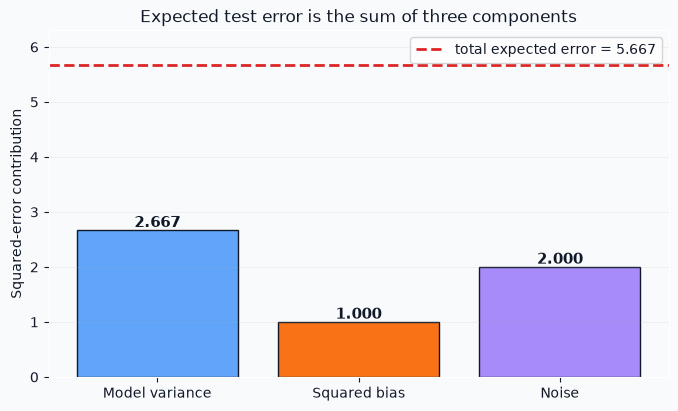

In [5]:
component_names: list[str] = ["Model variance", "Squared bias", "Noise"]
component_values: list[float] = [model_variance, squared_bias, noise_variance]
component_colors: list[str] = ["#60a5fa", "#f97316", "#a78bfa"]

bars_figure: Figure
bars_axis: Axes
bars_figure, bars_axis = plt.subplots(figsize=(8, 4.5), facecolor="#f8fafc")
bars_axis.set_facecolor("#f8fafc")
bars = bars_axis.bar(component_names, component_values, color=component_colors,
                     edgecolor="#111827")
for bar, value in zip(bars, component_values):
    bars_axis.text(bar.get_x() + bar.get_width() / 2, value + 0.06, f"{value:.3f}",
                   ha="center", color="#111827", fontweight="bold", fontsize=11)
bars_axis.axhline(expected_test_error, color="#dc2626", linestyle="--", linewidth=2,
                  label=f"total expected error = {expected_test_error:.3f}")
bars_axis.set(title="Expected test error is the sum of three components",
              ylabel="Squared-error contribution", ylim=(0, 6.3))
bars_axis.tick_params(colors="#111827"); bars_axis.title.set_color("#111827")
bars_axis.yaxis.label.set_color("#111827")
bars_axis.legend(facecolor="white", labelcolor="#111827"); bars_axis.grid(axis="y", alpha=0.2)
plt.show()


## Topic 7 — Move from one fixed input to all possible inputs


### 7.1 Every component can change with $x$

The **input domain** is the set or range of input values we want to consider. Equation 8.7 is calculated separately at each input position in that domain. Therefore, the following can all be functions of $x$:

- model variance;
- squared bias;
- noise variance.

A model may change little across retrainings where many training examples occur nearby, yet change substantially near the edge of the observed input range.


### 7.2 Plot the pointwise components from the repeated-fit experiment

The next plot uses the same $R=100$ fitted curves from Topic 3. Each vertical slice corresponds to the bias–variance decomposition at one fixed $x$.


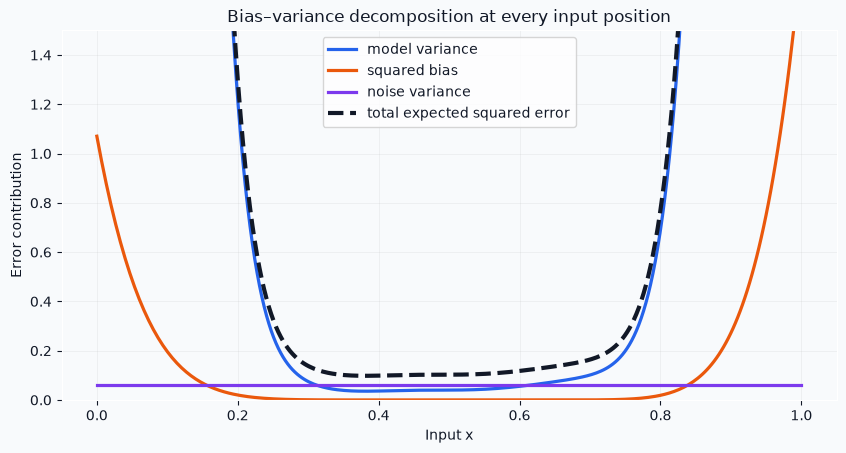

In [6]:
model_variance_curve: FloatArray = prediction_matrix.var(axis=0)
squared_bias_curve: FloatArray = (estimated_expected_model_curve - true_mean_curve) ** 2
noise_curve: FloatArray = np.full_like(x_grid, data_noise_standard_deviation ** 2)
total_error_curve: FloatArray = model_variance_curve + squared_bias_curve + noise_curve

components_figure: Figure
components_axis: Axes
components_figure, components_axis = plt.subplots(figsize=(10, 4.8), facecolor="#f8fafc")
components_axis.set_facecolor("#f8fafc")
components_axis.plot(x_grid, model_variance_curve, color="#2563eb", linewidth=2.3,
                     label="model variance")
components_axis.plot(x_grid, squared_bias_curve, color="#ea580c", linewidth=2.3,
                     label="squared bias")
components_axis.plot(x_grid, noise_curve, color="#7c3aed", linewidth=2.3,
                     label="noise variance")
components_axis.plot(x_grid, total_error_curve, color="#111827", linewidth=3,
                     linestyle="--", label="total expected squared error")
components_axis.set(title="Bias–variance decomposition at every input position",
                    xlabel="Input x", ylabel="Error contribution")
components_axis.set_ylim(0, min(1.5, float(np.quantile(total_error_curve, 0.97)) * 1.2))
components_axis.tick_params(colors="#111827"); components_axis.title.set_color("#111827")
components_axis.xaxis.label.set_color("#111827"); components_axis.yaxis.label.set_color("#111827")
components_axis.legend(facecolor="white", labelcolor="#111827"); components_axis.grid(alpha=0.2)
plt.show()


### 7.3 Overall test error averages the pointwise equation over $x$

To summarize performance across the input population, average both sides of Equation 8.7 using $\Pr(x)$:

$$
\mathbb E_x
\left[
\mathbb E_{\mathcal D}\mathbb E_y[L[x]]
\right].
$$

In a finite representative test set with inputs $x_1,\ldots,x_M$, this outer expectation is approximated by

$$
\frac{1}{M}
\sum_{i=1}^{M}L[x_i].
$$

Here, $M$ is the number of test examples. The test-set average approximates the population average over inputs.


## Topic 8 — Interpret the three terms carefully


### 8.1 Statistical bias is not a neural-network bias parameter

A neural-network layer may contain an intercept parameter often called a bias, such as $b$ in $z=wx+b$.

That is different from statistical bias:

$$
\operatorname{Bias}[x]=f_{\mu}[x]-\mu[x].
$$

Statistical bias measures systematic prediction error after averaging over possible training datasets.


### 8.2 Model variance is not a variance predicted by one model

Model variance compares separately retrained models:

$$
\mathbb E_{\mathcal D}
[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2].
$$

A **probabilistic model** predicts values that describe a target distribution rather than only one point prediction. Such a model may output a target variance for one fitted model. That output describes uncertainty in $y[x]$ conditional on one model and input. It is a different object from variability across retrained models.


### 8.3 Noise is irreducible only relative to the available input

The noise term describes target variation not explained by the current input features:

$$
\sigma^2=\mathbb E_y[(y[x]-\mu[x])^2].
$$

A better fitting algorithm cannot eliminate this term while using the same information. However, adding informative measurements may explain variation that previously appeared random.


### 8.4 Equation 8.7 relies on specific conditions

The clean additive result assumes:

- squared-error loss;
- fresh target noise is independent of the sampled training dataset, meaning that changing the sampled dataset does not change the target-generating process used for a fresh observation;
- the required means and variances are finite;
- the decomposition is first evaluated at a fixed $x$.

The book uses one constant $\sigma^2$ for every input. This is called **homoscedastic noise**. If noise spread changes with $x$, it is called **heteroscedastic noise**, and the pointwise noise term becomes $\sigma^2[x]$.


### 8.5 Sequential reading checklist

When reading any line in the derivation, ask in this order:

1. What does each symbol denote?
2. What is fixed?
3. What is random?
4. Which distribution supplies that randomness?
5. What calculation occurs before averaging?
6. Why was an intermediate mean inserted?
7. Which deviation has expectation zero?
8. Is “variance” describing targets or retrained models?
9. Is the equation at one fixed $x$ or averaged across $x$?

The final statement is:

$$
\text{expected squared test error at }x
=
\text{model variance}
+
\text{squared bias}
+
\text{noise variance}.
$$
